## Arima para series de tiempo


Basado en: https://github.com/Manishms18/Air-Passengers-Time-Series-Analysis/blob/master/Air_Passenger_with_explanations.ipynb

y en https://machinelearningmastery.com/arima-for-time-series-forecasting-with-python/

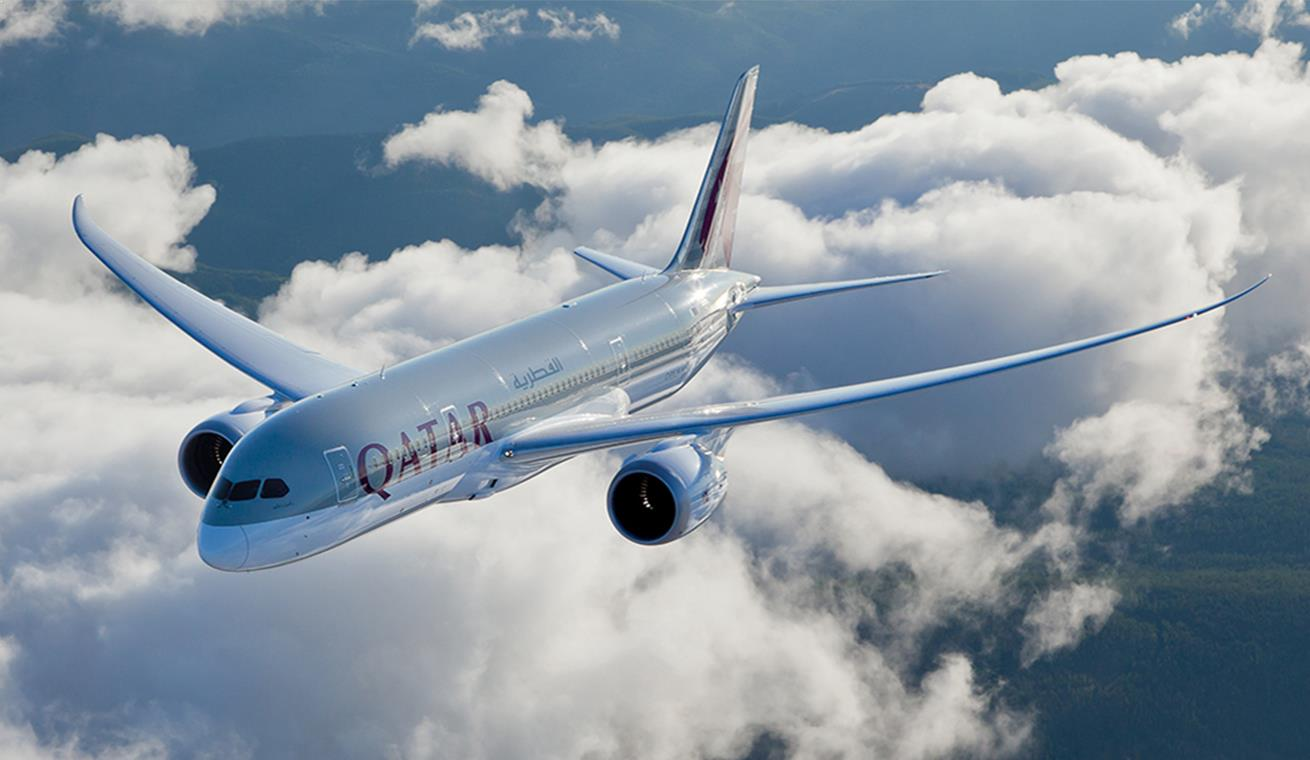

##### Importaciones

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
%matplotlib inline
from matplotlib.pylab import rcParams
from datetime import datetime
import warnings
plt.rcParams.update({'font.size': 14})
warnings.filterwarnings('ignore')


##### Cargar los datos:

In [12]:
data=pd.read_csv(r'AirlinePassengers.csv')
data.shape

(144, 2)

In [13]:
data

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


Poner la fecha como índice del dataframe.

In [14]:
data['Month']=pd.to_datetime(data['Month'], infer_datetime_format=True)
data=data.set_index(['Month'])
data

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


### Visualizar

Siempre es un paso muy importante al inicio pintar la serie, para entender bien cómo son nuestros datos.



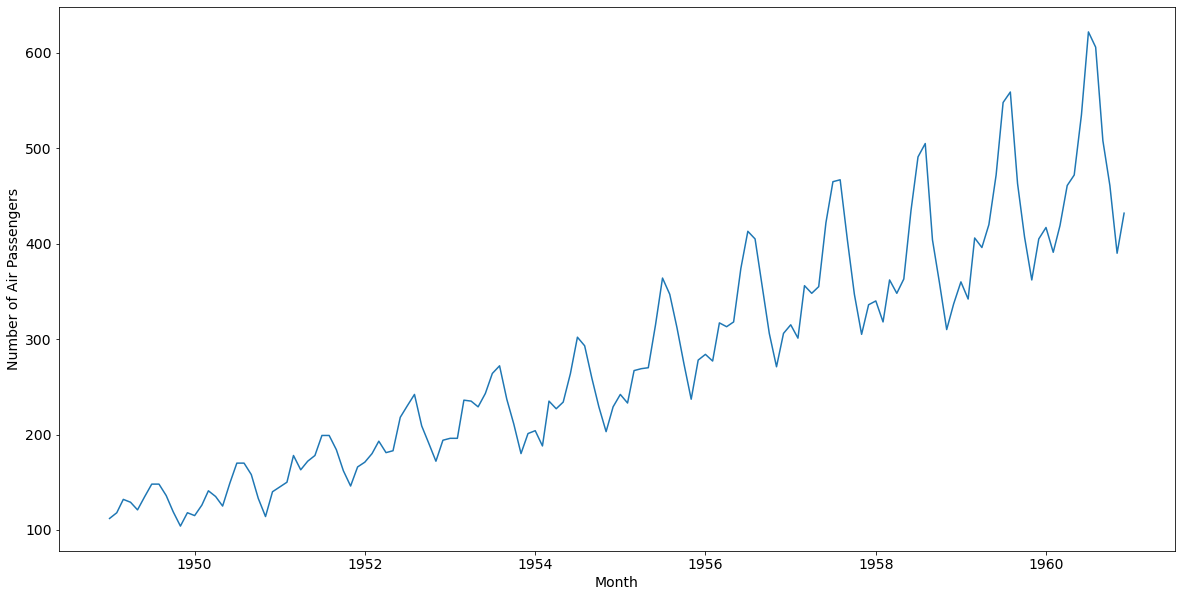

In [15]:
plt.figure(figsize=(20,10))
plt.xlabel("Month")
plt.ylabel("Number of Air Passengers")
plt.plot(data)

De la misma forma, resulta valioso hacer un primer análisis con esta visualización.

Podemos por ejemplo ver que:

- Se tienen datos de forma mensual, desde 1949 a 1960, para el número de pasajeros en una aerolinea

- Se nota que hay una tendencia creciente clara en los datos (no es estacionaria)

- Hay picos y valles cada 12 meses (estacionalidad)

- Los picos parecen volverse mas pronunciados con el tiempo

- Se nota claramente que las observaciones están relacionadas entre si, es decir, hay dependencia (común en una serie de tiempo)

- No hay outliers evidentes en la serie de datos (ni puntos individuales outliers ni grupos de puntos outliers)

- En términos generales, la serie parece tener una dinámica similar en toda su historia (siempre parece tener las mismas ondulaciones a través del tiempo)



### Estacionariedad

Recordemos que para usar ARIMA de forma adecuada, debemos tener una serie estacionaria. Usemos una prueba estadística para ver si la serie es o no es estacionaria.

La hipótesis nula  de esta prueba es que la serie no es estacionaria.


In [16]:
from statsmodels.tsa.stattools import adfuller
print('Dickey-Fuller Test: ')
dftest=adfuller(data['Passengers'], autolag='AIC')
dfoutput=pd.Series(dftest[0:4], index=['Test Statistic','p-value','Lags Used','No. of Obs'])
for key,value in dftest[4].items():
    dfoutput['Critical Value (%s)'%key] = value
print(dfoutput)

Dickey-Fuller Test: 
Test Statistic            0.815369
p-value                   0.991880
Lags Used                13.000000
No. of Obs              130.000000
Critical Value (1%)      -3.481682
Critical Value (5%)      -2.884042
Critical Value (10%)     -2.578770
dtype: float64


Vemos que el p-valor es de 0.99, claramente no se puede rechazar la hipótesis nula, por lo que no hay suficiente evidencia para decir que nuestra serie si sea estacionaria.

Por ende, miremos la serie en diferencias a ver si esta si es estacionaria.

Para llevarla a diferencias, se usa el método diff() de pandas.



In [17]:
### Llevar la serie a diferencias
diff_data = data.diff().dropna()
diff_data

,Passengers
Month,
1949-02-01,6.0
1949-03-01,14.0
1949-04-01,-3.0
1949-05-01,-8.0
1949-06-01,14.0
...,...
1960-08-01,-16.0
1960-09-01,-98.0
1960-10-01,-47.0


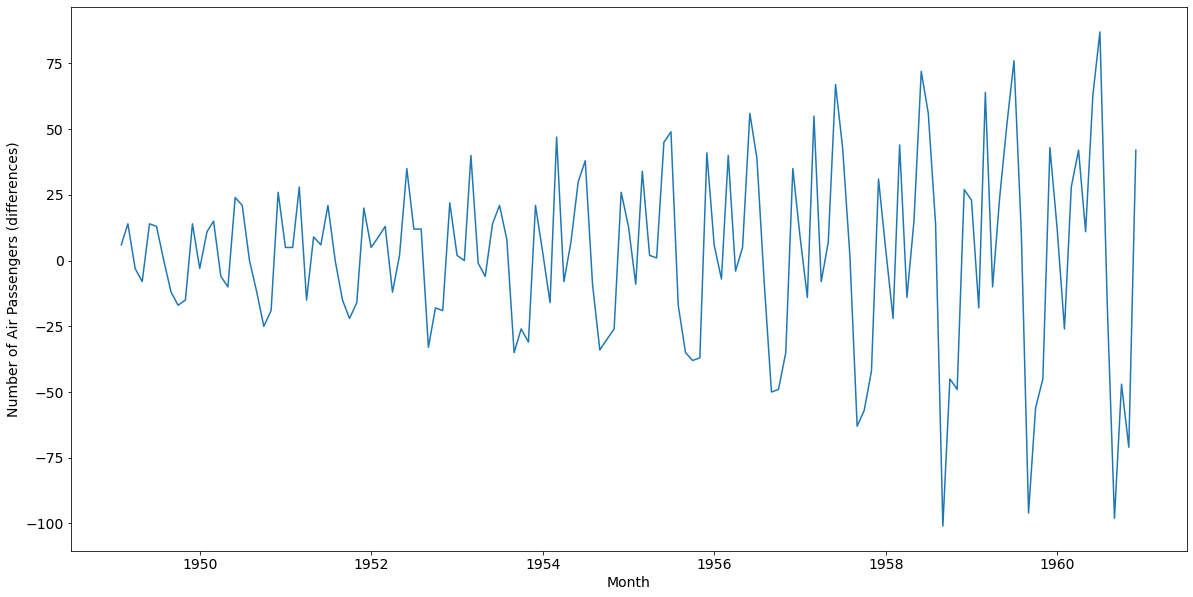

In [18]:
plt.figure(figsize=(20,10))
plt.xlabel("Month")
plt.ylabel("Number of Air Passengers (differences)")
plt.plot(diff_data)

In [19]:
print('Dickey-Fuller Test: ')
dftest=adfuller(diff_data['Passengers'], autolag='AIC')
dfoutput=pd.Series(dftest[0:4], index=['Test Statistic','p-value','Lags Used','No. of Obs'])
for key,value in dftest[4].items():
    dfoutput['Critical Value (%s)'%key] = value
print(dfoutput)

Dickey-Fuller Test: 
Test Statistic           -2.829267
p-value                   0.054213
Lags Used                12.000000
No. of Obs              130.000000
Critical Value (1%)      -3.481682
Critical Value (5%)      -2.884042
Critical Value (10%)     -2.578770
dtype: float64


El p-valor es de 0.054. A pesar de que aún queda un poquito de ambigüedad, al nivel de confianza de 94% ya podemos concluir que la serie si es estacionaria, lo cual es suficiente para este ejemplo.

Esto indica que la serie debe diferenciarse una vez para ser estacionaria. Esto hay que tenerlo en cuenta más adelante al construir nuestro modelo ARIMA.

### División de los datos en entrenamiento y prueba

Antes de continuar, vamos a aplicar un procesamiento en los datos que es muy común en problemas de analítica.

Lo que vamos a hacer es dividir nuestros datos en datos de entrenamiento y datos de prueba.

Esto se hace para que el modelo que construyamos sea entrenado y ajustado solamente con el subconjunto de los datos que son de entrenamiento. De esta forma, luego podemos evaluar el modelo con los datos de prueba para ver cómo es su rendimiento. Esto se hace para tener más similitudes con un comportamiento real: cuando vaya a usar el modelo en condiciones reales, lo usaré sobre datos que no existían y que el modelo jamás había visto. Por eso debo usarlo sobre los datos que deje aparte como conjunto de prueba, en vez de sobre los datos de entrenamiento.

En series de tiempo, este proceso se suele hacer de forma cronológica: simplemente asumo que una pequeña parte final de mi serie de tiempo serán datos de prueba, y el resto serán los de entrenamiento.

En este caso, asumiré que el 80% inicial de la serie serán datos de entrenamiento, y el 20% restante serán los de prueba.



In [20]:
# Dividir en conjuntos de entrenamiento (train) y prueba (test)
X = data.copy()
size = int(len(X) * 0.8)
train, test = X[0:size], X[size:len(X)]


Pintemos nuestros datos de entrenamiento y de prueba:

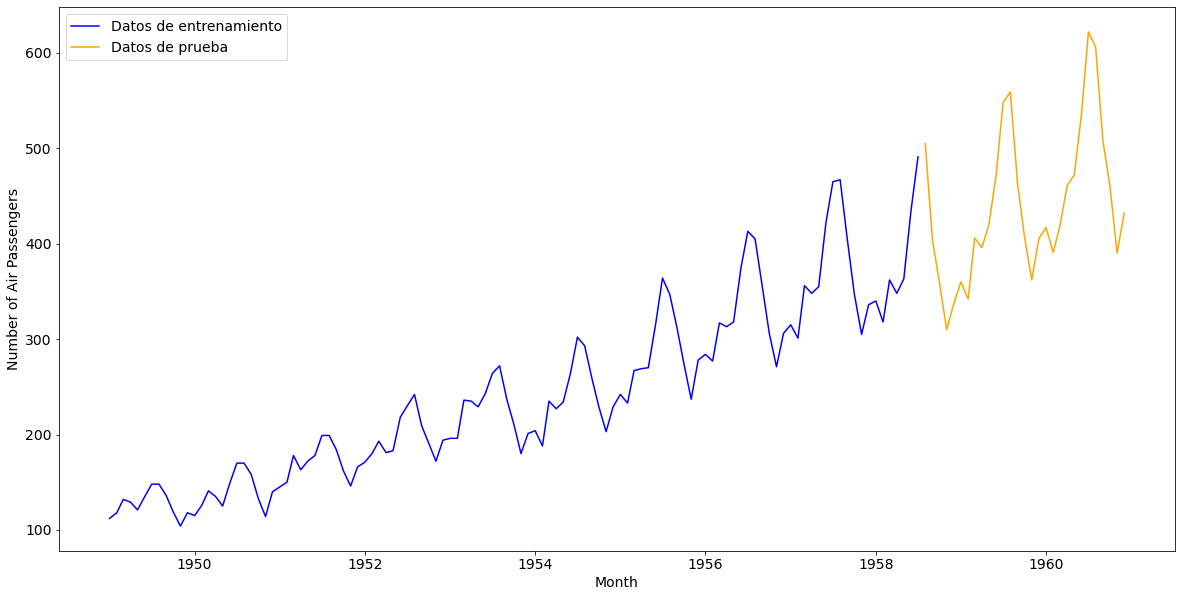

In [21]:
### Pintar la serie
plt.figure(figsize=(20,10))
plt.xlabel("Month")
plt.ylabel("Number of Air Passengers")
plt.plot(train, color='blue', label='Datos de entrenamiento')
plt.plot(test, color='orange', label='Datos de prueba')
plt.legend()


Así, nuestros datos de entrenamiento van desde 1948 hasta mediados de 1958, y de ahí en adelante estarán los datos de prueba.

Ahora sí estamos listos para empezar a construir modelos de series de tiempo para nuestra problemática.

# Modelación 

### Construcción del modelo ARIMA

Recordemos que los hiperparámetros de un modelo ARIMA son (p,d,q), donde p es para la parte "AR" (cuántos rezagos incluir), d es para la parte "I" (cuántas veces integrar o diferenciar la serie) y la q es para la parte "MA" (cuántos medias móviles del error se incluirán).

Cómo ya vimos que luego de diferenciar una vez la serie era estacionaria, ya sabemos que nuestra "d" será igual a 1. (Ojo: si la serie original ya era estacionaria, la "d" debía ser de 0). NOTA: el valor de la d siempre dependerá de cuántas veces hay que diferenciar al serie (en la mayoría de los casos, esta d suele tomar valores de 0 o 1, pero a veces puede llegar a tomar valores más grandes si requiere diferenciarse varias veces hasta ser estacionaria).

Nos falta determinar entonces valores para la p y la q, además de agregar parte estacional si queremos.

Siempre en la parte de modelación debo probar y comparar varios modelos diferentes para finalmente elegir el mejor de ellos.

### AR(1)
Primero con el más básico, un AR(1), que equivaldría a una p=1 y q=0.

Se usa la librería statsmodels, en su modelo ARIMA.

Notar que le ponemos que el modelo debe diferenciarse, por lo que le ponemos los datos originales al modelo (sin diferenciar) y el modelo por dentro se encarga de diferenciarlos para su proceso.

plotting ARIMA model


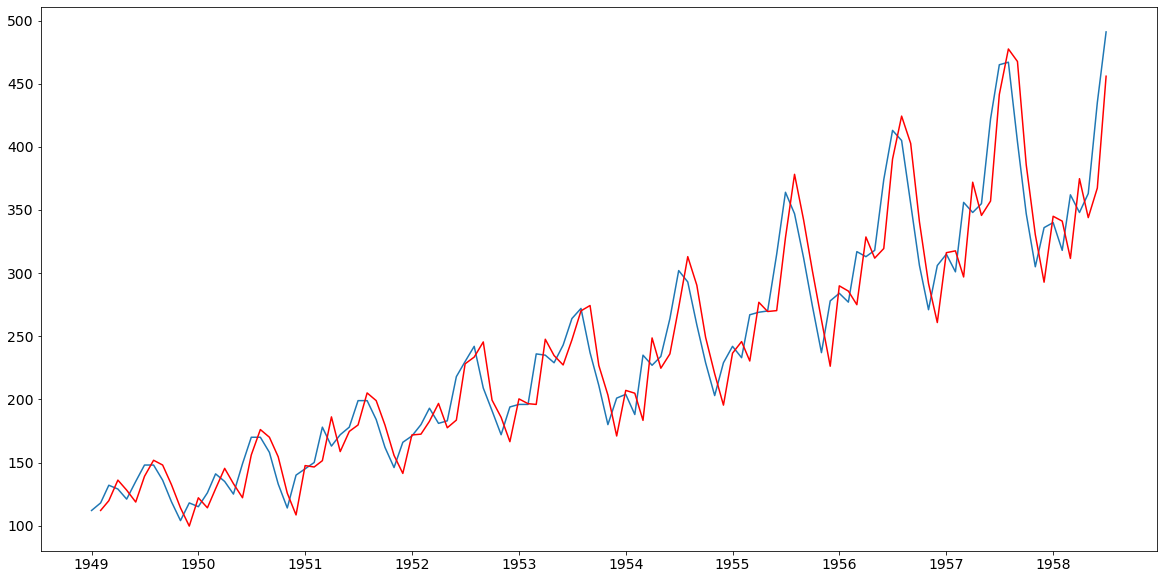

In [22]:
from statsmodels.tsa.arima.model import ARIMA
warnings.filterwarnings('ignore')

plt.figure(figsize=(20,10))

model=ARIMA(train, order=(1,1,0)) # p, d, q
results=model.fit()
plt.plot(train)

prediccion_ar1 = results.fittedvalues[1:] ## Devuelve la prediccion en niveles

plt.plot(prediccion_ar1, color='red')
print('plotting ARIMA model')

La gráfica anterior nos muestra un buen primer ajuste para el modelo. Sin embargo, una peculiaridad que siempre se nota en los AR(1) es que la predicción pareciera estar "desplazada" de la real. 

Esto ocurre obviamente debido a que, al ser un AR(1), yo reacciono hoy a lo que ocurrió ayer, mañana a lo que ocurrió hoy, etc., por eso se da ese efecto visual de que esté desplazada.

Para mirar que tan bueno es su ajuste, es necesario usar una métrica de ajuste. En este caso, nótese que estamos ajustando el modelo con toda la serie y evaluándolo también con toda la serie. Esto va a dar una predicción un poco sesgada ya que deberíamos hacer una partición train-test como en machine learning. Sin embargo, por ahora podemos dejar así este experimento.

Usemos como métricas el MSE y el MAE (el MSE suele tener mejores propiedas estadísticas pero el MAE es más fácil de interpretar para las personas de negocio). Para recordar cómo se calculan, ver por ejemplo: https://hackernoon.com/es/mis-notas-en-mae-vs-mse-error-metrics.


In [23]:
### Metricas

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

mse = mean_squared_error(train['Passengers'][1:], prediccion_ar1)
mae = mean_absolute_error(train['Passengers'][1:], prediccion_ar1)


print('MSE: '+str(mse))
print('MAE: '+str(mae))

#mse = mean_squared_error(y_true, y_pred)

MSE: 664.7585262114126
MAE: 20.631420139954212


Como hemos dicho siempre, el MSE es difícil de interpretar. Sin embargo, un MAE de 20.6 nos muestra que en promedio se suele equivocar en alrededor de 20.6 pasajeros por mes, lo cual suena bien para un primer modelo.

### MA(1)

Ahora probemos el MA(1).

plotting ARIMA model


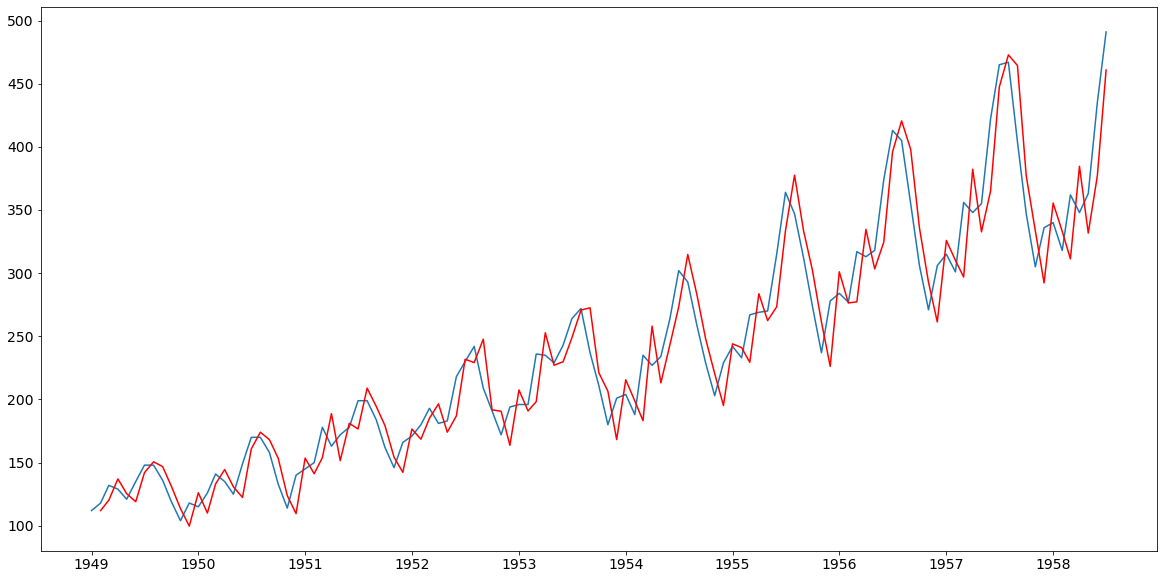

In [24]:
plt.figure(figsize=(20,10))

model=ARIMA(train, order=(0,1,1)) # p, d, q
results=model.fit()
plt.plot(train)

prediccion_ma1 = results.fittedvalues[1:]

plt.plot(prediccion_ma1, color='red')
print('plotting ARIMA model')

Visualmente también se ve decente, y es díficil diferenciarlo del AR(1). Miremos las métricas.

In [25]:
### Metricas
mse = mean_squared_error(train['Passengers'][1:], prediccion_ma1)
mae = mean_absolute_error(train['Passengers'][1:], prediccion_ma1)


print('MSE: '+str(mse))
print('MAE: '+str(mae))

#mse = mean_squared_error(y_true, y_pred)

MSE: 636.173748284064
MAE: 20.736503306233548


Dan un poco peor, pero no es mucha la diferencia.

### ARIMA

Ahora si, metamósle al modelo toda la potencia: tanto la parte AR como la MA.

Por ejemplo, construyamos un ARIMA(3,1,3).

plotting ARIMA model


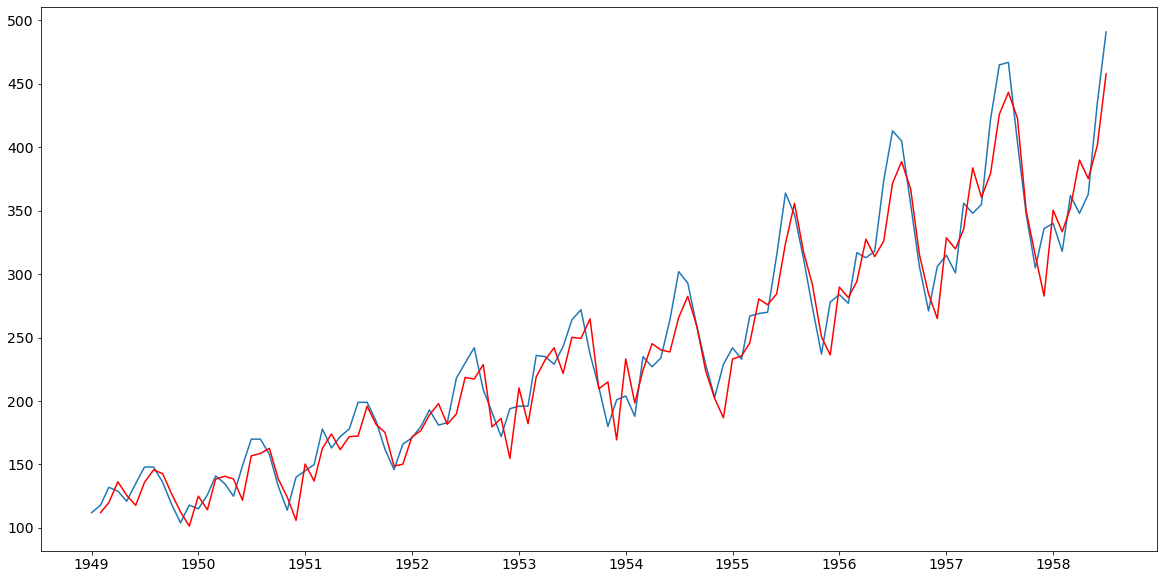

In [26]:

plt.figure(figsize=(20,10))

model=ARIMA(train, order=(3,1,3)) # p, d, q
results=model.fit()
plt.plot(train)

prediccion_arima =  results.fittedvalues[1:]

plt.plot(prediccion_arima, color='red')
print('plotting ARIMA model')

Del gráfico no es muy fácil notar si es mejor o peor que los anteriores, aunque por ejemplo en la parte final si parece tener un ajuste más cercano. Miremos las métricas.

In [27]:
### Metricas
mse = mean_squared_error(train['Passengers'][1:], prediccion_arima)
mae = mean_absolute_error(train['Passengers'][1:], prediccion_arima)


print('MSE: '+str(mse))
print('MAE: '+str(mae))

#mse = mean_squared_error(y_true, y_pred)

MSE: 412.53786610167595
MAE: 16.165840909415337


Estas métricas se nota que sí son mucho mejores que las del AR(1) y MA(1), teniendo por ende por ahora un mejor modelo.

Téngase en cuenta que en un ejercicio más completo, se esperaría evaluar muchas otras combinaciones posibles de (p,d,q) hasta llegar al que mejor resultado tenga, y se puede también comparar las métricas en el conjunto de prueba en vez de en  el conjunto de entrenamiento como se hizo aquí. 

### SARIMA

Claramente habíamos notado que la serie tiene una estacionalidad. Por dicha razón, incluyamos entonces el modelo SARIMA para los efectos estacionales.

Ensayemos por ejemplo agregar dos rezagos a los efectos estacionales y dos períodos de media móvil, además de diferenciarlos.

Esto quiere decir que en la parte estacional voy a poner:

- Una P de 2 (2 rezagos estacionales)
- Una D de 1 (diferenciar la parte estacional, sugerido hacerlo por simplicidad ya que igual ya diferencié la parte no estacional). La D por simplicidad se sugiere ponerle el mismo valor de la d; nótese que este valor a veces puede ser también cero si la serie original ya era estacionaria.
- Una Q de 2 (dos componentes de media móvil estacional)
- Una S de 12 (ya que cada 12 meses se repite el ciclo).

##### Pilas: aquí se pone S de 12 porque el ciclo ocurre cada 12 observaciones (12 meses en 1 año). Si mis datos estuvieran en frecuencia semanal, mi S probablemente sería de 52 ya que sería un ciclo (52 semanas en 1 año). O si estuviera en frecuencia horaria, mi S probablemente sería de 24 (un ciclo es cada día).

plotting ARIMA model


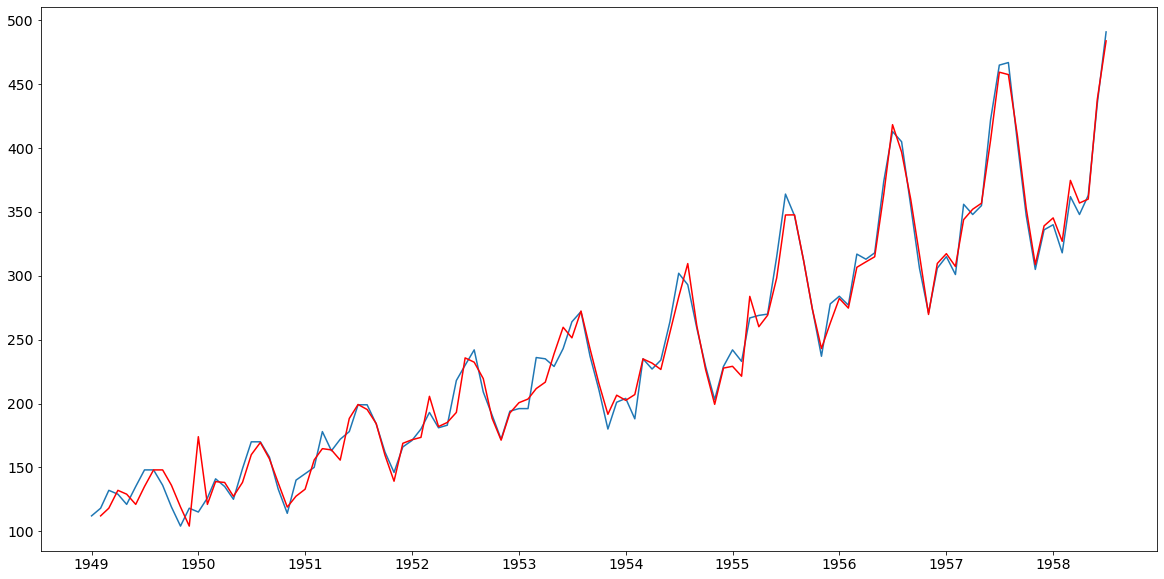

In [28]:

plt.figure(figsize=(20,10))

# Este es un ARIMA (3,1,3), pero además en la parte estacional pongo P,D,Q,S igual a 2,1,2,12. 
model=ARIMA(train, order=(3,1,3), seasonal_order=(2, 1, 2, 12) ) #


results=model.fit()
plt.plot(train)

prediccion_sarima = results.fittedvalues[1:]

plt.plot(prediccion_sarima, color='red')
print('plotting ARIMA model')

In [29]:
### Metricas
mse = mean_squared_error(train['Passengers'][1:], prediccion_sarima)
mae = mean_absolute_error(train['Passengers'][1:], prediccion_sarima)



print('MSE: '+str(mse))
print('MAE: '+str(mae))

#mse = mean_squared_error(y_true, y_pred)

MSE: 116.86993266697425
MAE: 7.7917850767151515


En este vemos una gran mejora con respecto a los anteriores, debido a que ya estamos logrando capturar la estacionalidad presente en nuestra serie.

### Ojo: Se deben comparar varias combinaciones de hiperparámetros (p, P, q, Q)
En un ejercicio de analítica (como el del proyecto), es usual comparar varios distintos tipos de modelo hasta llegar a uno con buenas métricas (por ejemplo, probar varias decenas de combinaciones de p, d, q y P,D,Q en el SARIMA y quedarse con las que tengan mejores métricas de error).

Por ejemplo, pudimos haber ensayado un SARIMA (3,1,3), (3,1,1,12) también:





In [30]:
 
model=ARIMA(train, order=(3,1,3), seasonal_order=(3, 1, 1, 12) ) #
results=model.fit()
prediccion_sarima = results.fittedvalues[1:]


### Metricas
mse = mean_squared_error(train['Passengers'][1:], prediccion_sarima)
mae = mean_absolute_error(train['Passengers'][1:], prediccion_sarima)



print('MSE: '+str(mse))
print('MAE: '+str(mae))



MSE: 112.73662197428997
MAE: 7.517850479462558


Note que al cambiar la P de 2 a 3 y la Q de 2 a 1 se obtuvo un modelo con mejores métricas que el anterior. Por ende, siempre se recomienda ensayar varios valores de p, P, q y Q (se recomienda probar varias combinaciones de estos pero máximo asignándoles un valor de aproximadamente 5  a cada uno).

#### Así, quedemonos por ahora con el SARIMA (3,1,3), (3,1,1,12) como nuestro modelo elegido.

In [31]:
#### Hiperparámetros elegidos
p_fin = 3
d_fin = 1
q_fin = 3

P_fin = 3
D_fin = 1
Q_fin = 1
S_fin = 12

### Evaluación

Ya seleccionamos nuestro SARIMA (3,1,3), (3,1,1,12) como el mejor modelo. 

Ahora, pasemos entonces a la fase de evaluación, donde revisaremos que los resultados que está arrojando nuestro modelo si sean apropiados.

Para lograr esto, probemos primero que sus residuos si sean ruido blanco, y luego validemos sus métricas finales en el conjunto de prueba.

Empecemos primero verificando: los residuos (errores) de un modelo ARIMA deben ser ruido blanco. Ruido blanco quiere decir que se cumplan 3 condiciones:

1. La media de los residuos es aproximadamente 0.
2. Los residuos son independientes entre si.
3. La varianza de los residuos es constante. 

Si los residuos no son ruido blanco, no cumple lo que dice la estadística, por lo que lo ideal es reajustar el modelo con otros hiperparámetros y repetir el proceso hasta que se cumpla esta condición.

In [32]:
residuos = results.resid[1:] ### Residuos del modelo

Miremos la gráfica de los residuos del modelo. 

¿Pueden identificar a qué punto en la gráfica de predicciones del SARIMA de más arriba corresponde el valor extremo de que está alrededor de 1950?

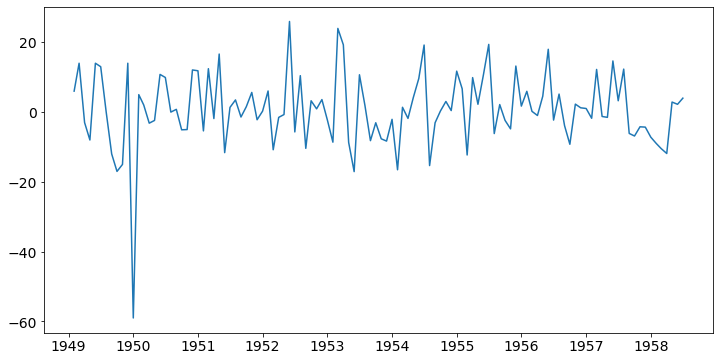

In [33]:
plt.figure(figsize=(12,6))

plt.plot(residuos)



Miremos entonces si se cumplen las 3 condiciones para que sean ruido blanco.

##### Condición 1

Para mirar la condición 1. Si de verdad logramos modelar completamente la tendencia, nuestros residuos deberían estar centrados en 0 (esto quiere decir que su media sea de aproximadamente 0).

In [34]:
np.mean(residuos)

0.6653048719291336

Teniendo en cuenta que los valores de la serie rondan los cientos, el valor obtenido no es muy lejano a 0, por lo que concluyo que su media si está más o menos alrededor de 0. 

Aquí es vital conocer la escala de mis datos: pensar que en este caso, un residuo medio de 0.67 pasajeros es muy bajo y casi imperceptible (menos de 1 pasajero de error promedio), por lo que si se parece a 0. Pero en algún otro ejemplo, por ejemplo si estuviera modelando precios de celulares en bitcoins, sé que un error medio de 0.67 BTC es bastante dinero y ahí no podría decir que ese valor sí se parece a 0.

##### Condición 2

Ahora, para la condición 2, usemos el test de Ljung-Box. Este test sirve para comprobar si nuestros residuos son independientes. Si son ruido blanco, se debería cumplir que sí sean independientes.

La hipótesis nula de este test es que los datos sí son independientes; la alternativa es que no lo son.

In [37]:
import statsmodels.api as sm
sm.stats.acorr_ljungbox(results.resid,  return_df=True)

,lb_stat,lb_pvalue
1,0.014362,0.904609
2,0.585314,0.746278
3,0.586100,0.899607
4,0.586470,0.964555
5,0.870477,0.972322
6,1.039760,0.984060
7,1.335032,0.987479
8,2.385110,0.966873
9,2.810681,0.971330
10,4.556583,0.918767


Con un p-valor mínimo de 0.74, no hay suficiente evidencia para rechazar la hipótesis nula de que los datos si son independientes, por lo que asumiremos que sí son independientes.

##### Condición 3

Por último, para la condición 3, para este curso, esto lo haremos simplemente de forma visual: comprobar que las oscilaciones de la serie no varíen notablemente a través del tiempo (es decir, que no cambie mucho el tamaño de las oscilaciones). 

Si miramos de nuevo la gráfica de los residuos, vemos que las oscilaciones no cambian mucho su tamaño a través del tiempo (a pesar de que hay outliers), por lo que  asumiremos que su varianza es constante, cumpliendo así la condición 3.



##### En resumen: 
Condición 1: La media de los residuos está más o menos alrededor de 0 (prácticamente de 0).

Condición 2: los residuos son independientes. 

Condición 3: la varianza parece ser constante a través del tiempo.

Por ende, concluyo que sí parecen ser ruido blanco, así que tengo luz verde para continuar con este modelo.

Si alguno de los tres anteriores hubiera dado otro resultado (media de los residuos muy lejana a 0, o no independientes o varianza no constante), debo buscar otro modelo antes de continuar (tendría que probar otros valores para p,d,q o P,D,Q,S).

### Métricas en prueba

Ahora que vimos que sí podría ser ruido blanco, evaluemos las métricas en el conjunto de prueba para saber realmente como se comportaría en condiciones reales.

Lo haremos de dos formas: con one-step ahead predictions y con multi-step ahead predictions.

##### One step ahead (un paso a la vez)
La de one-step ahead lo que hace es predecir de un paso a la vez. Para este caso, sería predecir un mes a la vez: predigo lo de febrero sabiendo lo que paso en enero, lo de marzo sabiendo lo de febrero, lo de abril sabiendo lo de marzo, y así sucesivamente.

Esta predicción es la que se debería utilizar si voy a reejecutar en cada período el modelo.

In [38]:
## Predicciones one step ahead (el codigo tarda un par de minutos)

history = list(train.values.copy())
predictions = list()
for t in range(len(test)):
	model =  ARIMA(history, order=(p_fin, d_fin, q_fin), seasonal_order=(P_fin, D_fin, Q_fin, S_fin) )
	model_fit = model.fit()
	output = model_fit.forecast()
	yhat = output[0]
	predictions.append(yhat)
	obs = test.values[t]
	history.append(obs)
	print('predicted=%f, expected=%f' % (yhat, obs))
    
# Métricas en prueba
mae = mean_absolute_error(test, predictions)
print('Test MAE: %.3f' % mae)
mse = mean_squared_error(test, predictions)
print('Test MSE: %.3f' % mse)


predicted=488.432688, expected=505.000000
predicted=439.712700, expected=404.000000
predicted=354.544824, expected=359.000000
predicted=315.213598, expected=310.000000
predicted=343.699367, expected=337.000000
predicted=353.627180, expected=360.000000
predicted=334.451959, expected=342.000000
predicted=389.291171, expected=406.000000
predicted=397.527585, expected=396.000000
predicted=405.145128, expected=420.000000
predicted=491.529991, expected=472.000000
predicted=535.309298, expected=548.000000
predicted=549.073409, expected=559.000000
predicted=457.991859, expected=463.000000
predicted=413.714138, expected=407.000000
predicted=355.966562, expected=362.000000
predicted=382.711609, expected=405.000000
predicted=421.767176, expected=417.000000
predicted=396.649354, expected=391.000000
predicted=449.365173, expected=419.000000
predicted=411.409527, expected=461.000000
predicted=464.718701, expected=472.000000
predicted=541.361322, expected=535.000000
predicted=603.026121, expected=622

Claramente se ve que se obtienen un MAE y MSE que aún son buenos pero no tan buenos como cuando lo usabamos con datos con los que entrenamos. 



##### Multi step ahead (Todos los períodos de una sola vez)

Por otro lado, si voy a ejecutar el modelo solo una vez para predecir todo el futuro, entonces debe predecir todos los meses futuros a partir de hoy, sin tener más información adicional.

In [39]:
## Predicciones Multi-step ahead 
history = list(train.values.copy())
predictions = list()

model =  ARIMA(history, order=(p_fin, d_fin, q_fin), seasonal_order=(P_fin, D_fin, Q_fin, S_fin) )
model_fit = model.fit()
output = model_fit.forecast(len(test))   ### Esta es la linea clave: predigo todo a la vez, por eso le paso "len(test)""
yhat = output
predictions = yhat

mae = mean_absolute_error(test, predictions)
print('Test MAE: %.3f' % mae)
mse = mean_squared_error(test, predictions)
print('Test MSE: %.3f' % mse)

Test MAE: 14.512
Test MSE: 327.920


Aquí obviamente al vernos obligados a predecir mucho más a futuro, nuestras métricas se ven mucho más afectadas. Sin embargo, se puede decir que siguen siendo decentes.

Esto tiene sentido con nuestra lógica: es más fácil predecir por ejemplo el precio del dólar de mañana que el precio del dolar dentro de 20 días.


### Despliegue (Predicciones a futuro)

Es necesario siempre permitir que nuestro modelo genere las predicciones a futuro, ya que precisamente para esto es que fue creado.

Así, lo primero que debo hacer es entrenar el modelo con todos mis datos:

In [40]:
### Modelo entrenado con todos los datos
model =  ARIMA(data, order=(p_fin, d_fin, q_fin), seasonal_order=(P_fin, D_fin, Q_fin, S_fin) ) #
# Mirar que pongo data para usar todos los datos
results=model.fit()
prediccion_sarima = results.fittedvalues[1:]


Con el siguiente código, generamos a futuro las predicciones del modelo SARIMA, con un intevalo de confianza del 95%, para los siguientes 24 meses a futuro: 

(Ojo: el valor que pongo en get_forecast es el número de períodos que quiero predecir a futuro en la escala en la que está mi serie (en este caso, esta mensual entonces son 24 meses).

In [41]:
### Predecir 24 pasos (meses) a futuro
x=results.get_forecast(steps=24)

### El valor predicho es
x_pred= x.predicted_mean
pd.DataFrame(x_pred)

,predicted_mean
1961-01-01,454.569591
1961-02-01,413.306052
1961-03-01,462.856143
1961-04-01,491.482406
1961-05-01,496.432208
1961-06-01,572.715053
1961-07-01,664.417481
1961-08-01,648.384360
1961-09-01,546.357371
1961-10-01,496.264424


In [42]:
### Y su intervalo de confianza es
x_ci = x.conf_int()
x_ci.head()

,lower Passengers,upper Passengers
1961-01-01,435.472078,473.667103
1961-02-01,390.418107,436.193996
1961-03-01,436.195247,489.517040
1961-04-01,462.876139,520.088674
1961-05-01,467.146060,525.718357


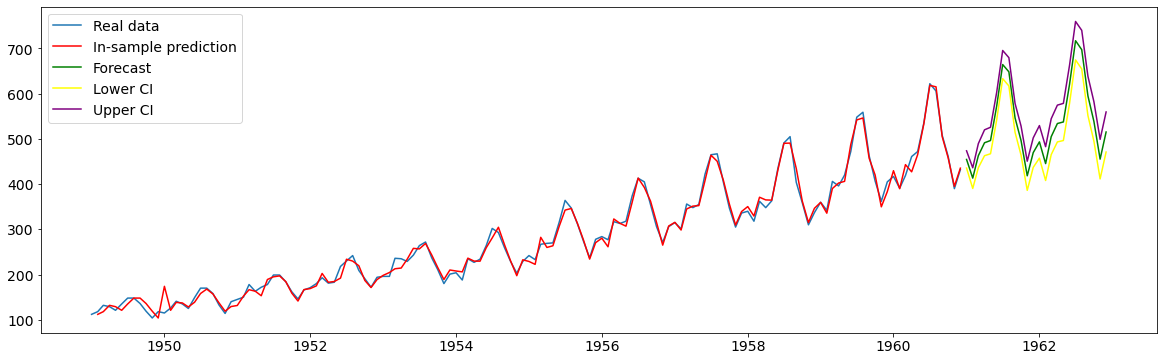

In [43]:
###  Graficar las predicciones a futuro
plt.figure(figsize=(20,6))

plt.plot(data, label='Real data')

prediccion_sarima = results.fittedvalues[1:]

plt.plot(prediccion_sarima, color='red', label='In-sample prediction')

## Forecast future
plt.plot(x_pred, color='green', label='Forecast')
plt.plot(x_ci['lower Passengers'], color='yellow', label='Lower CI')
plt.plot(x_ci['upper Passengers'], color='purple', label='Upper CI')

plt.legend()



### Predicciones reejecutadas en un día futuro

Hay que tener en cuenta que en un proyecto real, deberíamos tener este código listo para reentrenar el modelo con los datos actualizados y generar las predicciones a partir de la fecha final de los datos actualizados.

In [44]:
### Leer datos actualizados con nuevas fechas
data_new =pd.read_csv(r'AirlinePassengers_New.csv')
data_new['Month']=pd.to_datetime(data_new['Month'], infer_datetime_format=True)
data_new=data_new.set_index(['Month'])
data_new

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1961-02-01,452
1961-03-01,462
1961-04-01,437


In [45]:
### Predicciones actualizadas
model =  ARIMA(data_new, order=(p_fin, d_fin, q_fin), seasonal_order=(P_fin, D_fin, Q_fin, S_fin) )
results=model.fit()

x=results.get_forecast(steps=24)
x_pred= x.predicted_mean
x_ci = x.conf_int()

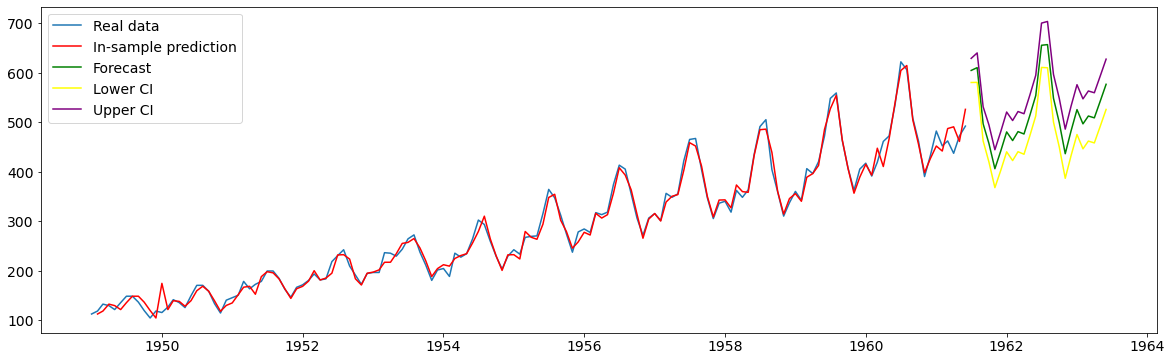

In [46]:
### Plot
plt.figure(figsize=(20,6))

plt.plot(data_new, label='Real data')

prediccion_sarima = results.fittedvalues[1:]

plt.plot(prediccion_sarima, color='red', label='In-sample prediction')


plt.plot(x_pred, color='green', label='Forecast')
plt.plot(x_ci['lower Passengers'], color='yellow', label='Lower CI')
plt.plot(x_ci['upper Passengers'], color='purple', label='Upper CI')

plt.legend()



In [47]:
## Las predicciones son
pd.DataFrame(x_pred)

,predicted_mean
1961-07-01,604.565477
1961-08-01,610.210007
1961-09-01,496.533588
1961-10-01,457.050414
1961-11-01,405.852279
1961-12-01,441.125689
1962-01-01,480.228081
1962-02-01,462.755121
1962-03-01,480.855317
1962-04-01,476.019534


### Ejercicio:

1. Encuentre un modelo de tipo ARIMA o SARIMA que supere las métricas del modelo aquí presentado en el conjunto de entrenamiento (cambiando los distintos hiperparámetros del modelo).

2. Verifique que los residuos de ese modelo sean ruido blanco.

3. Genere las métricas en el conjunto de prueba para dicho modelo (usando one step ahead y multi step ahead).

4. Genere las predicciones de este modelo a futuro para los próximos 3 años.

5. Ajuste el modelo elegido con los datos de AirlinePassengers_New.csv y genere las nuevas predicciones.